In [25]:
import pandas as pd 
import re 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, f1_score, roc_auc_score
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('klachten.csv').copy()
y = df['Product']
X = df['Omschrijving']

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [28]:
# initaliseren stop words en lemmatizer 
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [29]:
def preprocess_text(text):
    if pd.isna(text):
        return""
    
    text = text.lower() # lowercase maken 
    text = re.sub(r'[^a-z\s]', ' ', text) # speciale tekens verwijderen 
    return text 

def my_tokenizer(text):
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words] # stopwords verwijderen 
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatizen

    return tokens

In [30]:
vectorizer = TfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=my_tokenizer,
    analyzer='word',
    token_pattern=None
)

X_train_dfm = vectorizer.fit_transform(X_train)
X_test_dfm = vectorizer.transform(X_test)

# train model on document-feature matrix
model = LogisticRegression()
model.fit(X_train_dfm, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
# predicties
y_pred = model.predict(X_test_dfm)
y_proba = model.predict_proba(X_test_dfm)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# F1 score (multiclass)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", f1)

# AUC (multiclass)
auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print("AUC:", auc)

[[ 368    2   36   16   14   11]
 [   8  140   14   25   70   27]
 [  27    1  440   10   56   31]
 [  10    4    5  940   17   18]
 [   8   12   17   33 1065   94]
 [   2    7   27   12   95  805]]
F1: 0.8379559514514199
AUC: 0.9669870911114713


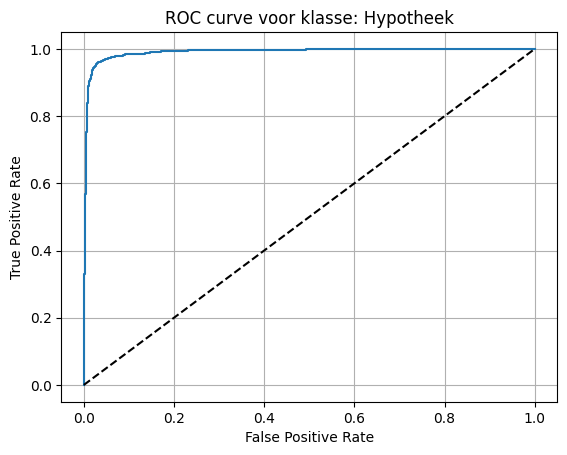

In [32]:
class_name = y_test.unique()[0]

class_index = list(model.classes_).index(class_name)
proba_class = y_proba[:, class_index]

fpr, tpr, thresholds = roc_curve((y_test == class_name).astype(int), proba_class)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve voor klasse: {class_name}")
plt.grid(True)
plt.show()

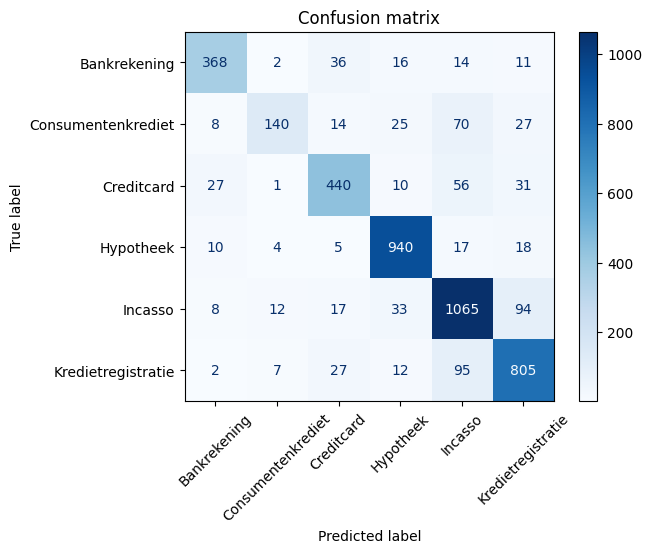

In [33]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.show()